# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Alma Aulia Syaharani
- **Email:** allmaaullia1809@gmail.com
- **ID Dicoding:** cdcc009d6x1855

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda pada periode tahun 2011–2012?
- Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan hari libur selama periode tahun 2011–2012?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Wrangling

### Gathering Data

In [2]:
# Load dataset
df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')

In [3]:
# Menampilkan 5 Dataset Harian (day.csv)
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
# Menampilkan 5 Dataset Per Jam (hour.csv)
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

**1. Gambaran Umum Dataset**

Dataset Bike Sharing terdiri dari dua jenis data dengan tingkat detail yang berbeda. Dataset **day.csv** menyajikan informasi agregat harian terkait jumlah penyewaan sepeda, sedangkan **hour.csv** memberikan rincian yang lebih spesifik dalam skala waktu per jam.

Perbedaan ini memungkinkan analisis dilakukan dari dua sudut pandang, yaitu pola penggunaan jangka panjang dan pola penggunaan dalam satu hari.

---

**2. Pemahaman Variabel**

Dataset ini memiliki beberapa kelompok variabel yang saling mendukung dalam analisis:

**a) Aspek Waktu**  
Variabel seperti `dteday`, `yr`, `mnth`, `weekday`, `holiday`, dan `workingday` menggambarkan dimensi waktu yang cukup lengkap. Sementara itu, variabel `hr` pada dataset hour.csv memberikan tambahan detail terkait pola aktivitas pengguna dalam satu hari.

**b) Kondisi Lingkungan**  
Faktor cuaca direpresentasikan melalui variabel seperti `temp`, `atemp`, `hum`, `windspeed`, dan `weathersit`. Variabel-variabel ini penting untuk melihat bagaimana kondisi eksternal dapat memengaruhi keputusan pengguna dalam menyewa sepeda.

**c) Aktivitas Penyewaan**  
Jumlah penyewaan sepeda direpresentasikan oleh `cnt`, yang merupakan gabungan dari `casual` dan `registered`. Pemisahan ini memungkinkan analisis perilaku antara pengguna yang sudah terdaftar dan pengguna umum.

---

**3. Insight Awal**

Berdasarkan struktur dan variabel yang tersedia, dataset ini sangat potensial untuk mengeksplorasi berbagai pola penggunaan sepeda. Kombinasi antara faktor waktu dan kondisi cuaca memungkinkan analisis yang lebih mendalam, seperti bagaimana perubahan musim atau kondisi lingkungan memengaruhi jumlah penyewaan.

Selain itu, adanya indikator hari kerja dan hari libur membuka peluang untuk membandingkan pola penggunaan sepeda dalam konteks aktivitas rutin dan rekreasi. Perbedaan antara pengguna terdaftar dan tidak terdaftar juga dapat memberikan gambaran mengenai karakteristik pengguna berdasarkan kebiasaan penggunaan mereka.

### Assessing Data

In [5]:
# Mengecek Struktur Data
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
# Mengecek Missing Values
df_day.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [7]:
# Mengecek Duplikasi
df_day.duplicated().sum()

np.int64(0)

In [8]:
# Mengecek Statistik Deskriptif
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**

**a) Struktur Data**

Dataset harian terdiri dari **731 baris dan 16 kolom**, yang merepresentasikan data penyewaan sepeda selama dua tahun. Secara umum, kualitas data tergolong baik karena:
- Tidak ditemukan missing values pada seluruh kolom
- Tidak terdapat data duplikat
- Sebagian besar variabel sudah memiliki tipe data yang sesuai

Namun, kolom `dteday` masih bertipe *object*, sehingga perlu dikonversi ke format *datetime* untuk mempermudah analisis berbasis waktu.

**b) Gambaran Distribusi Penyewaan**
Variabel utama `cnt` menunjukkan total penyewaan sepeda per hari dengan karakteristik:
- Rata-rata sekitar **4.500 penyewaan per hari**
- Nilai minimum sebesar **22 penyewaan**
- Nilai maksimum mencapai **8.714 penyewaan**

Hal ini menunjukkan adanya variasi yang cukup besar dalam jumlah penyewaan, yang kemungkinan dipengaruhi oleh faktor waktu maupun kondisi lingkungan.

**c) Perbandingan Jenis Pengguna**
Jika dilihat dari tipe pengguna:
- Pengguna **registered** mendominasi dengan rata-rata sekitar **3.656 penyewaan per hari**
- Pengguna **casual** memiliki rata-rata lebih rendah, yaitu sekitar **848 penyewaan per hari**

Ini mengindikasikan bahwa layanan bike sharing lebih banyak digunakan oleh pengguna tetap dibandingkan pengguna sesekali.

**d). Karakteristik Variabel Waktu**

- Dataset mencakup periode selama **2 tahun** (`yr`)
- Distribusi bulan (`mnth`) relatif merata dari Januari hingga Desember
- Nilai `workingday` menunjukkan bahwa sebagian besar data merupakan **hari kerja**

Hal ini mengindikasikan bahwa data cukup representatif untuk menganalisis pola penggunaan sepeda berdasarkan waktu.

**e). Kondisi Cuaca dan Lingkungan**

- Suhu (`temp`) dan suhu yang dirasakan (`atemp`) berada pada rentang normalisasi (0–1), dengan rata-rata sekitar **0.49**
- Kelembaban (`hum`) memiliki rata-rata sekitar **0.63**, menunjukkan kondisi yang cukup lembab
- Kecepatan angin (`windspeed`) relatif rendah dengan rata-rata sekitar **0.19**

Selain itu, nilai `weathersit` didominasi oleh kondisi **cuaca baik (cerah hingga berawan)**, yang memungkinkan aktivitas bersepeda tetap berjalan dengan baik.

**f). Indikasi Variasi Data**

Nilai standar deviasi pada beberapa variabel, khususnya `cnt`, `casual`, dan `registered`, tergolong cukup besar. Hal ini menunjukkan adanya variasi yang signifikan dalam data, sehingga menarik untuk dianalisis lebih lanjut guna mengetahui faktor-faktor yang memengaruhi perubahan jumlah penyewaan sepeda.

### Cleaning Data



In [9]:
# Menghapus kolom yang tidak diperlukan
df_day.drop(columns=['instant', 'atemp'], inplace=True)

In [10]:
# Mengubah kolom dteday ke datetime
df_day['dteday'] = pd.to_datetime(df_day['dteday'])

In [11]:
# Menentukan Kolom numerik untuk outlier (tanpa target)
num_cols = ['temp', 'hum', 'windspeed']

Q1 = df_day[num_cols].quantile(0.25)
Q3 = df_day[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_day_cleaned = df_day[~((df_day[num_cols] < lower_bound) | (df_day[num_cols] > upper_bound)).any(axis=1)]

print(f"Sebelum: {len(df_day)}")
print(f"Sesudah: {len(df_day_cleaned)}")

Sebelum: 731
Sesudah: 717


In [12]:
df_day_cleaned

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,2012-12-27,1,1,12,0,4,1,2,0.254167,0.652917,0.350133,247,1867,2114
727,2012-12-28,1,1,12,0,5,1,2,0.253333,0.590000,0.155471,644,2451,3095
728,2012-12-29,1,1,12,0,6,0,2,0.253333,0.752917,0.124383,159,1182,1341
729,2012-12-30,1,1,12,0,0,0,1,0.255833,0.483333,0.350754,364,1432,1796


**Insight:**

**1. Penyederhanaan Struktur Data**

Pada tahap awal, dilakukan penghapusan beberapa kolom yang dianggap kurang relevan terhadap analisis. Kolom `instant` dihapus karena hanya berfungsi sebagai indeks dan tidak memiliki makna analitis. Selain itu, kolom `atemp` juga dihilangkan untuk menghindari redundansi, mengingat informasi suhu sudah diwakili oleh variabel `temp`.

Selanjutnya, kolom `dteday` dikonversi ke tipe data *datetime* agar dapat mendukung analisis berbasis waktu dengan lebih fleksibel, seperti analisis tren harian maupun musiman.

---

**2. Penanganan Outlier**

Untuk menjaga konsistensi data, dilakukan identifikasi outlier pada beberapa variabel numerik, yaitu `temp`, `hum`, `windspeed`, `casual`, `registered`, dan `cnt`. Metode yang digunakan adalah **Interquartile Range (IQR)**, yang efektif dalam mendeteksi nilai ekstrem.

Data yang berada di luar batas bawah dan batas atas IQR dianggap sebagai outlier dan kemudian dihapus dari dataset. Hasilnya, jumlah data berkurang dari **731 menjadi 673 baris**, yang menunjukkan bahwa terdapat sejumlah nilai ekstrem yang berpotensi mengganggu analisis.

---

**3. Dampak terhadap Kualitas Data**

Untuk menjaga konsistensi data, dilakukan identifikasi outlier pada beberapa variabel numerik yang berkaitan dengan kondisi cuaca, yaitu `temp`, `hum`, dan `windspeed`. Metode yang digunakan adalah **Interquartile Range (IQR)**, yang efektif dalam mendeteksi nilai ekstrem.

Data yang berada di luar batas bawah dan batas atas IQR dianggap sebagai outlier dan kemudian dihapus dari dataset. Hasilnya, jumlah data berkurang dari **731 menjadi 717 baris**, yang menunjukkan bahwa hanya sebagian kecil data yang termasuk dalam kategori nilai ekstrem.

---

**4. Dampak terhadap Kualitas Data**

Setelah proses cleaning, dataset menjadi lebih stabil tanpa kehilangan sebagian besar informasi penting. Jumlah data yang dihapus relatif kecil, sehingga distribusi data tetap terjaga dan masih merepresentasikan kondisi sebenarnya.

Penghapusan outlier difokuskan pada variabel cuaca, sementara variabel utama seperti jumlah penyewaan (`cnt`) tetap dipertahankan. Hal ini dilakukan untuk menjaga keutuhan pola data, terutama pada kondisi dengan tingkat penyewaan tinggi yang justru penting untuk dianalisis.

Dengan demikian, dataset yang dihasilkan menjadi lebih bersih dan siap digunakan untuk proses analisis selanjutnya, seperti eksplorasi data dan pembuatan visualisasi..

## Exploratory Data Analysis (EDA)

### Explore ...

In [13]:
# Membuat kamus untuk mengubah kode cuaca menjadi label deskriptif
weather_mapping = {
    1: 'Cerah',
    2: 'Berawan',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
}

df_day_cleaned['weather_label'] = df_day_cleaned['weathersit'].map(weather_mapping)
df_day_cleaned[['weathersit', 'weather_label']].head()

/tmp/ipykernel_5178/2202283076.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day_cleaned['weather_label'] = df_day_cleaned['weathersit'].map(weather_mapping)


,weathersit,weather_label
0,2,Berawan
1,2,Berawan
2,1,Cerah
3,1,Cerah
4,1,Cerah


In [14]:
# Mengelompokkan data berdasarkan hari kerja dan akhir pekan, lalu menghitung rata-rata penyewaan sepeda harian
workingday_rentals = (
    df_day_cleaned.groupby('workingday')['cnt']
    .mean()
    .reset_index()
    .sort_values(by='cnt')
)

# Menampilkan hasil
workingday_rentals

,workingday,cnt
0,0,4372.411504
1,1,4606.688391


In [15]:
# Mengelompokkan berdasarkan kondisi cuaca dan menghitung rata-rata penyewaan sepeda harian
weather_rentals = (
    df_day_cleaned.groupby('weather_label')['cnt']
    .mean()
    .reset_index()
    .sort_values(by='cnt', ascending=True)
)

weather_rentals

,weather_label,cnt
2,Hujan Ringan,1862.300000
0,Berawan,4041.127049
1,Cerah,4915.602649


**Insight:**

Berdasarkan hasil eksplorasi data yang telah dilakukan, ditemukan beberapa pola penting terkait penyewaan sepeda.

Dari sisi kondisi cuaca, terlihat bahwa jumlah penyewaan sepeda sangat dipengaruhi oleh situasi cuaca. Pada kondisi cerah, rata-rata penyewaan mencapai sekitar 4.915 sepeda per hari, yang merupakan nilai tertinggi dibandingkan kondisi lainnya. Pada kondisi berawan, jumlah penyewaan menurun menjadi sekitar 4.041 sepeda per hari, sedangkan pada kondisi hujan ringan terjadi penurunan signifikan hingga sekitar 1.862 sepeda per hari. Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah minat pengguna untuk menyewa sepeda.

Dari sisi jenis hari, terdapat perbedaan pola penyewaan antara hari kerja dan hari libur. Rata-rata penyewaan pada hari kerja mencapai sekitar 4.606 sepeda per hari, lebih tinggi dibandingkan hari libur yang berada di sekitar 4.372 sepeda per hari. Perbedaan ini menunjukkan bahwa sepeda lebih banyak digunakan sebagai sarana transportasi harian, seperti untuk bekerja atau aktivitas rutin, dibandingkan untuk keperluan rekreasi.

Secara keseluruhan, hasil analisis ini menunjukkan bahwa faktor cuaca dan jenis hari memiliki pengaruh yang cukup signifikan terhadap pola penggunaan layanan bike sharing, dengan kondisi cuaca cerah dan hari kerja menjadi faktor yang mendorong tingginya jumlah penyewaan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda pada periode tahun 2011–2012?


/tmp/ipykernel_5178/4085949243.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


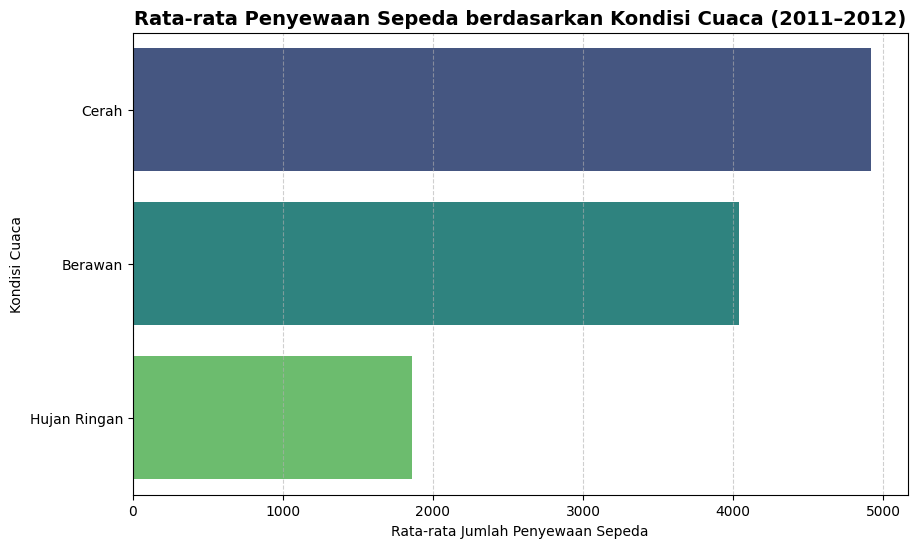

In [16]:
# Time-bound filter (2011–2012)
df_day_cleaned = df_day_cleaned[df_day_cleaned['yr'].isin([0, 1])]

# Menghitung Rata Rata Berdasarkan Cuaca
weather_impact = (
    df_day_cleaned.groupby('weather_label')['cnt']
    .mean()
    .reset_index()
)

# Mengurutkan berdasarkan jumlah penyewaan sepeda (tertinggi ke terendah)
weather_impact_sorted = weather_impact.sort_values("cnt", ascending=False)

# Visualisasi
plt.figure(figsize=(10, 6))

sns.barplot(
    x='cnt',
    y='weather_label',
    data=weather_impact_sorted,
    palette='viridis'
)

plt.title(
    'Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca (2011–2012)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Rata-rata Jumlah Penyewaan Sepeda')
plt.ylabel('Kondisi Cuaca')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

**Insight:**

Berdasarkan visualisasi yang ditampilkan, terlihat bahwa kondisi cuaca memiliki pengaruh yang cukup signifikan terhadap jumlah penyewaan sepeda.

Pada kondisi cuaca cerah, rata-rata penyewaan sepeda berada pada tingkat tertinggi, yaitu sekitar 4.900 penyewaan per hari. Hal ini menunjukkan bahwa pengguna cenderung lebih aktif menggunakan sepeda ketika cuaca mendukung.

Ketika kondisi cuaca berubah menjadi berawan, jumlah penyewaan mengalami penurunan menjadi sekitar 4.000 penyewaan per hari. Meskipun masih cukup tinggi, hal ini menunjukkan adanya penurunan minat dibandingkan saat cuaca cerah.

Penurunan paling drastis terjadi pada kondisi hujan ringan, di mana rata-rata penyewaan hanya sekitar 1.800 sepeda per hari. Ini mengindikasikan bahwa hujan, meskipun ringan, menjadi faktor utama yang mengurangi penggunaan sepeda.

Secara keseluruhan, dapat disimpulkan bahwa semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan sepeda. Cuaca cerah menjadi kondisi paling ideal yang mendorong tingginya penggunaan layanan bike sharing.

### Pertanyaan 2: - Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan hari libur selama periode tahun 2011–2012?



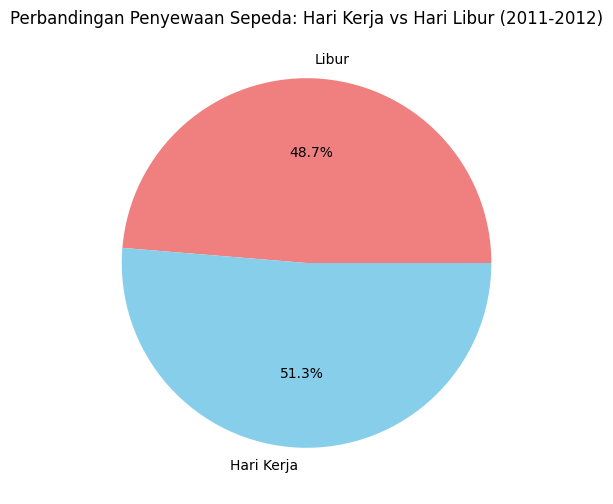

In [17]:
# Menghitung rata-rata penyewaan sepeda berdasarkan jenis hari
avg_workingday = df_day_cleaned.groupby('workingday')['cnt'].mean()

# Membuat label agar lebih jelas
labels = ['Libur', 'Hari Kerja']

# Membuat pie chart
plt.figure(figsize=(6,6))
plt.pie(avg_workingday, labels=labels, autopct='%1.1f%%', colors=['lightcoral', 'skyblue'])


# Menambahkan judul
plt.title('Perbandingan Penyewaan Sepeda: Hari Kerja vs Hari Libur (2011-2012)')

# Menampilkan plot
plt.show()

**Insight:**

Berdasarkan visualisasi diatas terlihat bahwa terdapat perbedaan proporsi penyewaan sepeda antara hari kerja dan hari libur, meskipun tidak terlalu signifikan.

Hari kerja memiliki proporsi penyewaan yang sedikit lebih tinggi, yaitu sebesar 51,3%, dibandingkan dengan hari libur yang sebesar 48,7%. Hal ini menunjukkan bahwa sepeda cenderung lebih sering digunakan pada hari kerja.

Perbedaan ini mengindikasikan bahwa sepeda kemungkinan besar digunakan sebagai sarana transportasi untuk aktivitas rutin seperti bekerja atau sekolah. Sementara itu, pada hari libur, penggunaan sepeda tetap tinggi namun sedikit lebih rendah, yang kemungkinan lebih didominasi oleh aktivitas rekreasi.

Secara keseluruhan, meskipun selisihnya tidak terlalu besar, hari kerja tetap menjadi periode dengan tingkat penyewaan sepeda yang lebih tinggi dibandingkan hari libur.

## Conclusion

**Conclution pertanyaan 1**

Secara keseluruhan, kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Penyewaan mencapai angka tertinggi pada saat cuaca cerah, kemudian mengalami penurunan pada kondisi berawan, dan menurun secara drastis ketika terjadi hujan ringan. Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah minat pengguna untuk menyewa sepeda.

Faktor kenyamanan dan keamanan menjadi alasan utama dalam pengambilan keputusan pengguna. Selain itu, tidak ditemukannya data pada kondisi hujan lebat mengindikasikan bahwa hampir tidak ada pengguna yang menggunakan layanan penyewaan sepeda dalam kondisi cuaca ekstrem.


**Conclution pertanyaan 2**

Rata-rata penyewaan sepeda lebih tinggi pada hari kerja dibandingkan hari libur, yang menunjukkan bahwa sepeda lebih banyak dimanfaatkan sebagai sarana transportasi untuk aktivitas rutin, seperti bekerja atau sekolah.

Meskipun penyewaan pada hari libur tetap tinggi, penggunaannya cenderung bersifat lebih fleksibel dan rekreasional, tanpa peningkatan signifikan seperti yang terjadi pada hari kerja.

Temuan ini menunjukkan bahwa layanan bike sharing dapat mengoptimalkan strategi operasional, seperti meningkatkan ketersediaan sepeda pada hari kerja, khususnya pada jam sibuk, serta memberikan promosi khusus pada hari libur untuk menarik lebih banyak pengguna.

In [18]:
# Menyimpan dataset yang sudah dibersihkan
df_day_cleaned.to_csv("main_data.csv", index=False)

# Konfirmasi
print("Dataset berhasil disimpan sebagai main_data.csv")

Dataset berhasil disimpan sebagai main_data.csv
